In [ ]:
# 🧠 CREDIT CARD FRAUD DETECTION PROJECT

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Step 2: Load dataset
df = pd.read_csv("creditcard.csv")
print("✅ Data Loaded Successfully!")

# Step 3: Basic info
print("\nDataset Preview:")
display(df.head())

print("\nData Info:")
print(df.info())

print("\nMissing Values per Column:")
print(df.isnull().sum().sum(), " total missing values")

# Step 4: Data Summary
print("\nClass distribution:")
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df, palette='Set2')
plt.title("Fraud (1) vs Non-Fraud (0) Transactions")
plt.show()

# Step 5: Normalize the 'Amount' feature (only numeric column not scaled)
scaler = StandardScaler()
df['Normalized_Amount'] = scaler.fit_transform(df[['Amount']])
df.drop(columns=['Amount', 'Time'], inplace=True)

# Step 6: Split into features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Step 7: Handle class imbalance using SMOTE (oversampling minority class)
print("\nBefore SMOTE:", y.value_counts().to_dict())
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print("After SMOTE:", y_res.value_counts().to_dict())

# Step 8: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# Step 9: Train models

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Step 10: Evaluate Models
print("\n📊 Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

print("\n📊 Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

# Step 11: Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Logistic Regression Confusion Matrix')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Random Forest Confusion Matrix')

plt.show()

# Step 12: ROC Curve and AUC Score
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Step 13: Model Comparison Summary
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

compare = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [lr_report['1']['precision'], rf_report['1']['precision']],
    'Recall': [lr_report['1']['recall'], rf_report['1']['recall']],
    'F1-Score': [lr_report['1']['f1-score'], rf_report['1']['f1-score']],
    'AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)]
})

print("\n✅ Model Comparison:")
display(compare)


In [1]:
# 🧠 CREDIT CARD FRAUD DETECTION PROJECT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load dataset from local folder (same directory as notebook)
df = pd.read_csv("creditcard.csv")
print("✅ Data Loaded Successfully!")

✅ Data Loaded Successfully!


In [3]:
# Display first few rows and basic info
print("\nDataset Preview:")
display(df.head())

print("\nData Info:")
print(df.info())

print("\nTotal Missing Values:", df.isnull().sum().sum())



Dataset Preview:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


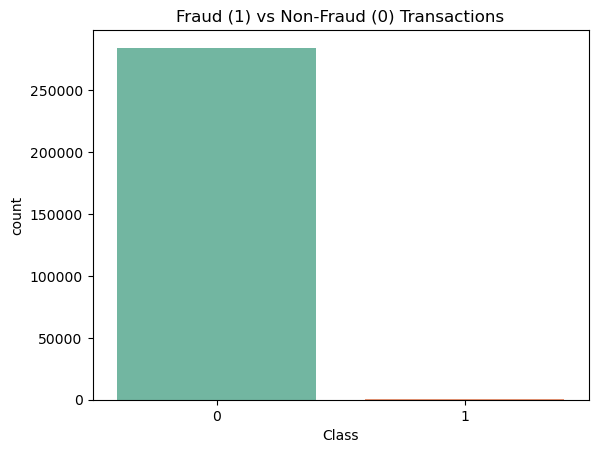

In [4]:
# Check for imbalance in fraud (1) vs non-fraud (0)
print("\nClass distribution:")
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df, palette='Set2')
plt.title("Fraud (1) vs Non-Fraud (0) Transactions")
plt.show()

In [5]:
# Normalize 'Amount' and drop 'Time'
scaler = StandardScaler()
df['Normalized_Amount'] = scaler.fit_transform(df[['Amount']])
df.drop(columns=['Amount', 'Time'], inplace=True)

print("✅ Normalization Done!")
display(df.head())

✅ Normalization Done!


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Normalized_Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


In [6]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print("Feature Shape:", X.shape)
print("Target Distribution:\n", y.value_counts())

Feature Shape: (284807, 29)
Target Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [7]:
# Apply SMOTE oversampling
print("\nBefore SMOTE:", y.value_counts().to_dict())
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print("After SMOTE:", y_res.value_counts().to_dict())


Before SMOTE: {0: 284315, 1: 492}
After SMOTE: {0: 284315, 1: 284315}


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (454904, 29)
Test Shape: (113726, 29)


In [9]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

print("✅ Logistic Regression Model Trained!")

✅ Logistic Regression Model Trained!


In [10]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("✅ Random Forest Model Trained!")

✅ Random Forest Model Trained!



📊 Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     56863
           1       0.97      0.92      0.94     56863

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726



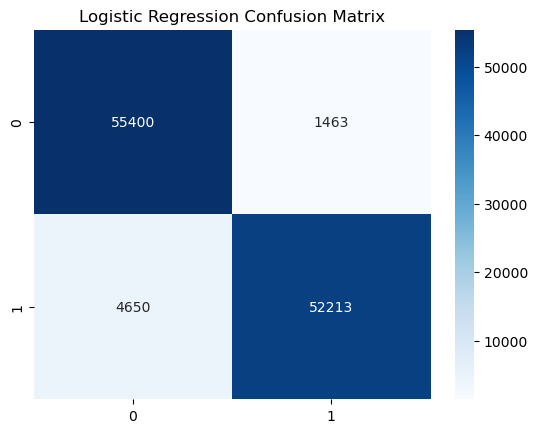

In [11]:
print("\n📊 Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


📊 Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



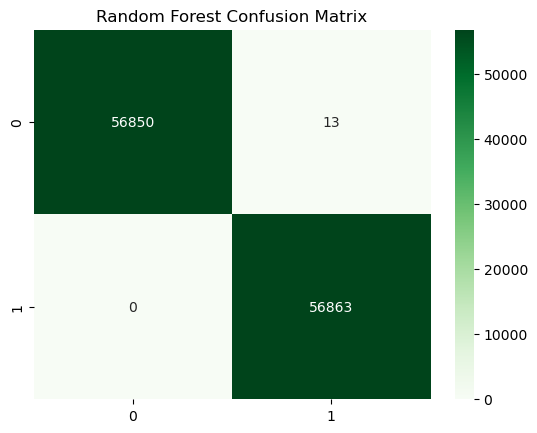

In [12]:
print("\n📊 Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.show()

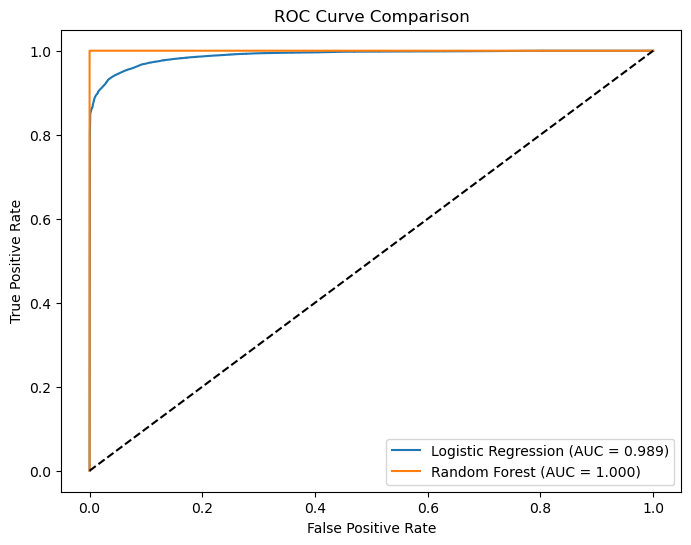

In [13]:
# ROC Curve for both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [14]:
# Compare metrics for both models
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

compare = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [lr_report['1']['precision'], rf_report['1']['precision']],
    'Recall': [lr_report['1']['recall'], rf_report['1']['recall']],
    'F1-Score': [lr_report['1']['f1-score'], rf_report['1']['f1-score']],
    'AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)]
})

print("\n✅ Model Comparison:")
display(compare)


✅ Model Comparison:


,Model,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.972744,0.918225,0.944698,0.989244
1,Random Forest,0.999771,1.000000,0.999886,1.000000
